# VAR Point-Estimation Showcase Notebook

This notebook is a **presentation-style walkthrough** of the VAR point-estimation project.

It focuses on:
- data used in the multivariate setup,
- the VAR(2) design structure,
- model families compared under point estimation,
- rolling one-step forecast outputs and risk metrics,
- saved artifacts (CSV + figures).

## Core design at a glance

- Response dimension: **4** (SPY, QQQ, DIA, IWN returns)
- Lag order: **p = 2**
- Predictor dimension: **9**  
  \(1 + 4	imes2 = 9\)

The goal is to let a TA/reviewer understand the project workflow without opening internal `src/` files.


In [1]:
# Imports and setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import DATA_DIR, RESULTS_DIR
from src.var_point_estimation.data import DEFAULT_SERIES, load_var_return_frame, build_var2_design
from src.var_point_estimation.models import GaussianVARPointModel, StudentTVARPointModel, MixtureVARPointModel
from src.run_var_point_estimation import run_var_point_estimation_workflow

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path('.').resolve()
print('Project root:', PROJECT_ROOT)
print('Data dir:', DATA_DIR)
print('Results dir:', RESULTS_DIR)


Project root: /Users/stewarttao/Downloads/2025-26Spring JHU major courses/Probabilistic Machine Learning /Final Project/PMLPJ_SiboTao_Part
Data dir: /Users/stewarttao/Downloads/2025-26Spring JHU major courses/Probabilistic Machine Learning /Final Project/PMLPJ_SiboTao_Part/test_data/Daily
Results dir: /Users/stewarttao/Downloads/2025-26Spring JHU major courses/Probabilistic Machine Learning /Final Project/PMLPJ_SiboTao_Part/results


## 1) Load dataset and basic overview

We load the merged 4-asset return dataset (inner join on `date`) using the project utility.
Columns:
- `date`: timestamp
- `SPY`, `QQQ`, `DIA`, `IWN`: daily log returns


In [2]:
series_names = DEFAULT_SERIES.copy()
returns_df = load_var_return_frame(Path(DATA_DIR), series_names=series_names)

print('Shape:', returns_df.shape)
returns_df.head()


Shape: (6022, 5)


,date,SPY,QQQ,DIA,IWN
0,2002-01-03,1.127519,3.406775,0.975425,1.156449
1,2002-01-04,0.665375,0.408802,0.857495,0.847332
2,2002-01-07,-0.708118,-1.110050,-0.612907,-1.100651
3,2002-01-08,-0.231511,0.677149,-0.457057,0.803877
4,2002-01-09,-0.818595,-0.920103,-0.557779,-0.389629


In [3]:
returns_df.describe().T


,count,mean,min,25%,50%,75%,max,std
date,6022,2014-01-15 19:35:46.130853632,2002-01-03 00:00:00,2008-01-02 06:00:00,2013-12-23 12:00:00,2020-02-23 06:00:00,2026-02-19 00:00:00,NaN
SPY,6022.0,0.039765,-11.588661,-0.422883,0.071508,0.587678,19.98574,1.23087
QQQ,6022.0,0.047137,-12.759215,-0.591458,0.114366,0.760547,11.479906,1.438481
DIA,6022.0,0.02625,-13.841813,-0.436024,0.053485,0.549501,10.764325,1.146447
IWN,6022.0,0.051765,-14.064349,-0.686723,0.068304,0.810789,110.866185,2.084706


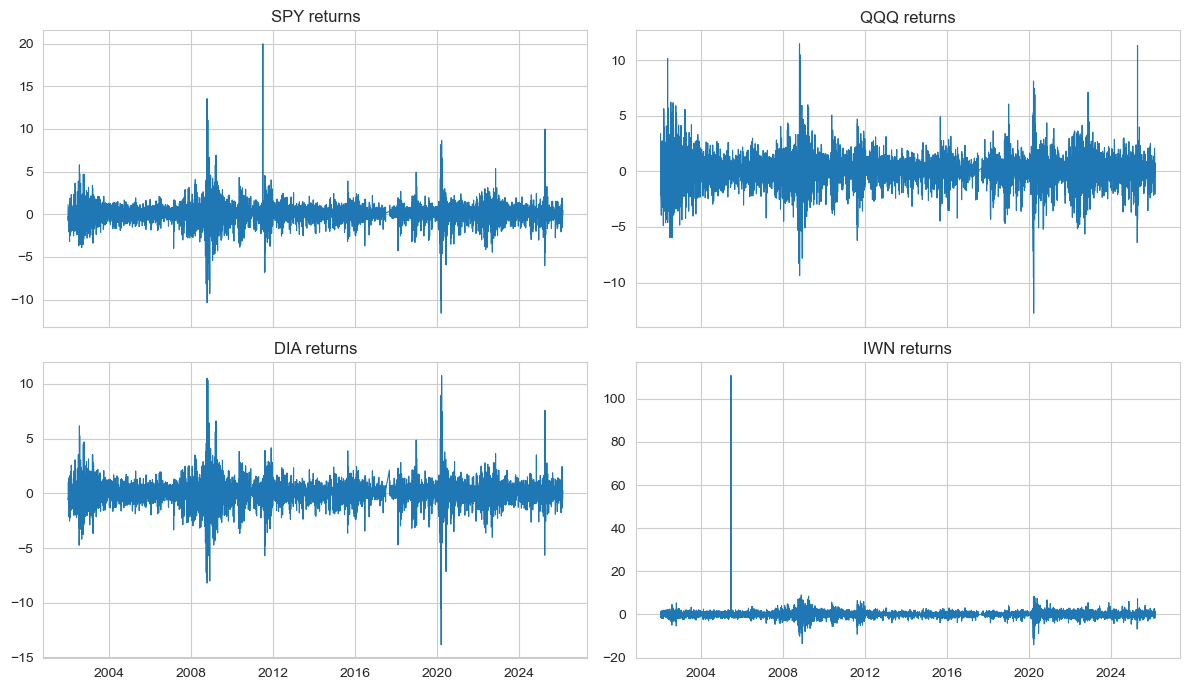

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, col in zip(axes.flatten(), series_names):
    ax.plot(returns_df['date'], returns_df[col], linewidth=0.8)
    ax.set_title(f'{col} returns')
plt.tight_layout()
plt.show()


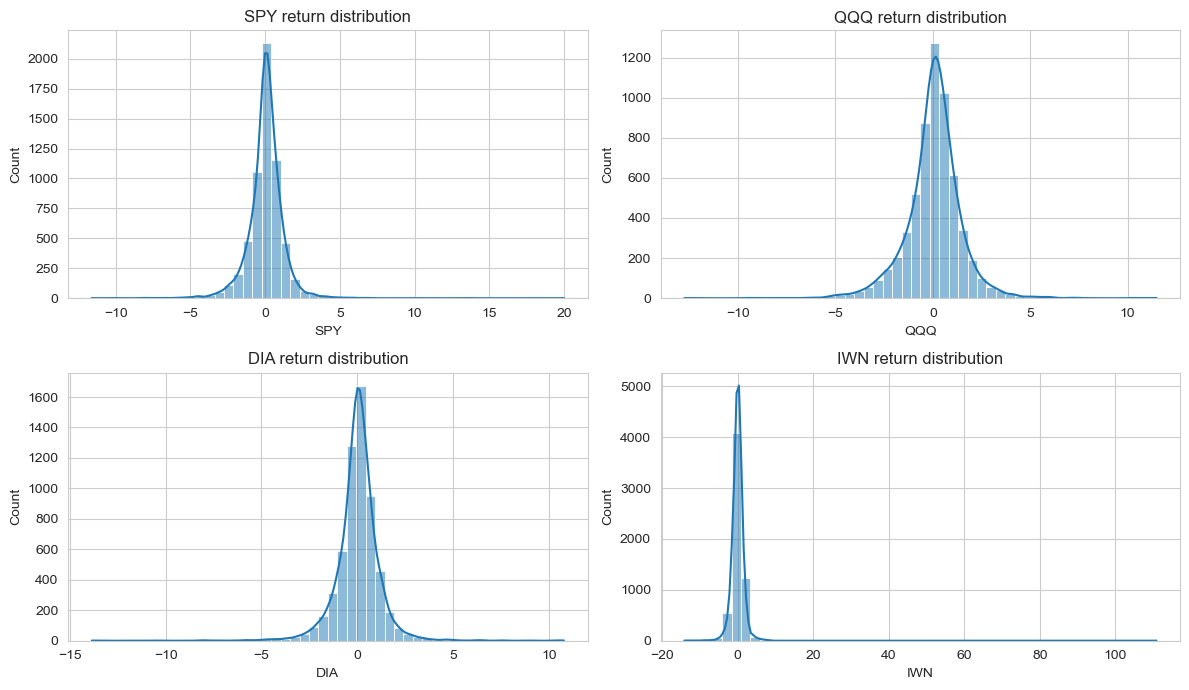

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flatten(), series_names):
    sns.histplot(returns_df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f'{col} return distribution')
plt.tight_layout()
plt.show()


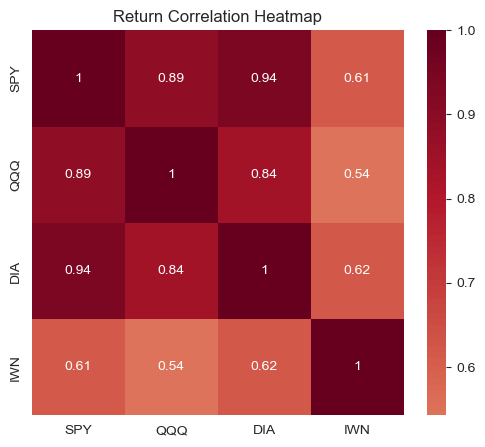

In [6]:
plt.figure(figsize=(6,5))
cor = returns_df[series_names].corr()
sns.heatmap(cor, annot=True, cmap='RdBu_r', center=0)
plt.title('Return Correlation Heatmap')
plt.show()


## 2) VAR(2) design matrix construction

We explicitly build the design:

\[
X_t = [1, Y_{t-1}, Y_{t-2}] \in \mathbb{R}^9, \quad Y_t \in \mathbb{R}^4
\]

Feature order used in this notebook:
- `intercept`
- `SPY_lag1, QQQ_lag1, DIA_lag1, IWN_lag1`
- `SPY_lag2, QQQ_lag2, DIA_lag2, IWN_lag2`


In [7]:
X, Y, aligned_dates = build_var2_design(returns_df, target_cols=series_names)
feature_names = ['intercept'] + [f'{c}_lag1' for c in series_names] + [f'{c}_lag2' for c in series_names]

print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('Aligned dates:', aligned_dates.min(), '->', aligned_dates.max())

pd.DataFrame(X[:5], columns=feature_names)


X shape: (6020, 9)
Y shape: (6020, 4)
Aligned dates: 2002-01-07 00:00:00 -> 2026-02-19 00:00:00


,intercept,SPY_lag1,QQQ_lag1,DIA_lag1,IWN_lag1,SPY_lag2,QQQ_lag2,DIA_lag2,IWN_lag2
0,1.0,0.665375,0.408802,0.857495,0.847332,1.127519,3.406775,0.975425,1.156449
1,1.0,-0.708118,-1.110050,-0.612907,-1.100651,0.665375,0.408802,0.857495,0.847332
2,1.0,-0.231511,0.677149,-0.457057,0.803877,-0.708118,-1.110050,-0.612907,-1.100651
3,1.0,-0.818595,-0.920103,-0.557779,-0.389629,-0.231511,0.677149,-0.457057,0.803877
4,1.0,0.440274,0.654627,-0.260187,0.045996,-0.818595,-0.920103,-0.557779,-0.389629


In [8]:
pd.DataFrame(Y[:5], columns=series_names)


,SPY,QQQ,DIA,IWN
0,-0.708118,-1.110050,-0.612907,-1.100651
1,-0.231511,0.677149,-0.457057,0.803877
2,-0.818595,-0.920103,-0.557779,-0.389629
3,0.440274,0.654627,-0.260187,0.045996
4,-0.986917,-1.289085,-0.801087,-1.015034


## 3) Point-estimation models included

This project compares three innovation specifications under the **same VAR mean structure**:

1. **Gaussian VAR**: OLS coefficient estimation with one covariance matrix.
2. **Student-t VAR**: iterative reweighting to handle heavy tails.
3. **Mixture VAR**: Gaussian mixture innovations via EM for flexible shock behavior.


In [9]:
models_demo = {
    'gaussian': GaussianVARPointModel(target_cols=series_names),
    'student_t': StudentTVARPointModel(target_cols=series_names, nu=5.0),
    'mixture': MixtureVARPointModel(target_cols=series_names, n_components=2),
}
list(models_demo.keys())


['gaussian', 'student_t', 'mixture']

## 4) Run main VAR point-estimation workflow

We run the existing workflow runner with moderate settings for demonstration.
(You can scale up `window_size`, decrease `step_size`, or increase `n_sim` for final experiments.)


In [10]:
existing_run_dirs = {p.name for p in Path(RESULTS_DIR).glob('*') if p.is_dir()}

outputs = run_var_point_estimation_workflow(
    series_names=series_names,
    window_size=400,
    step_size=5,
    n_sim=1000,
    alpha=0.05,
    nu=5.0,
    n_components=2,
)

new_run_dirs = [p for p in Path(RESULTS_DIR).glob('*') if p.is_dir() and p.name not in existing_run_dirs]
if new_run_dirs:
    latest_run_dir = sorted(new_run_dirs)[-1]
else:
    # fallback: use lexicographically latest timestamp directory
    all_dirs = sorted([p for p in Path(RESULTS_DIR).glob('*') if p.is_dir()])
    latest_run_dir = all_dirs[-1] if all_dirs else None

print('Latest VAR run dir:', latest_run_dir)
outputs['comparison']


Latest VAR run dir: /Users/stewarttao/Downloads/2025-26Spring JHU major courses/Probabilistic Machine Learning /Final Project/PMLPJ_SiboTao_Part/results/20260323_184839


,model,avg_lps,n_forecasts,timestamp
0,gaussian,-3.696897,1125,20260323_184839
1,student_t,-3.552028,1125,20260323_184839
2,mixture,-3.683055,1125,20260323_184839


## 5) Inspect returned objects and saved artifacts

The workflow currently returns:
- merged data used,
- model comparison table.

It also writes per-model CSVs and figures to disk under the timestamped run directory.


In [11]:
print('Output keys:', list(outputs.keys()))
print('Data shape from outputs:', outputs['data'].shape)
print('Comparison shape:', outputs['comparison'].shape)
outputs['comparison']


Output keys: ['data', 'comparison']
Data shape from outputs: (6022, 5)
Comparison shape: (3, 4)


,model,avg_lps,n_forecasts,timestamp
0,gaussian,-3.696897,1125,20260323_184839
1,student_t,-3.552028,1125,20260323_184839
2,mixture,-3.683055,1125,20260323_184839


In [12]:
if latest_run_dir is not None:
    all_csv = sorted(latest_run_dir.rglob('*.csv'))
    all_png = sorted(latest_run_dir.rglob('*.png'))
    print('CSV artifacts:', len(all_csv))
    print('PNG artifacts:', len(all_png))
    pd.DataFrame({'csv_files': [str(p.relative_to(latest_run_dir)) for p in all_csv[:15]]})


CSV artifacts: 10
PNG artifacts: 15


## 6) Load and inspect key parameter tables

We read selected model parameter files from the saved outputs.


In [13]:
def find_file(run_dir: Path, model: str, prefix: str):
    files = sorted((run_dir / model / 'metrics').glob(f'{prefix}_{model}_*.csv'))
    return files[-1] if files else None

if latest_run_dir is not None:
    param_paths = {
        m: find_file(latest_run_dir, m, 'model_parameters')
        for m in ['gaussian', 'student_t', 'mixture']
    }
    param_paths


In [15]:
if latest_run_dir is not None:
    for model_name, pth in param_paths.items():
        print('', '='*18, model_name.upper(), '='*18)
        if pth is None:
            print('No parameter file found.')
            continue
        dfp = pd.read_csv(pth)
        display(dfp.head(12))


 ================== GAUSSIAN ==================


,parameter,target,value
0,intercept,SPY,0.052896
1,lag1_SPY,SPY,-0.687978
2,lag1_QQQ,SPY,0.225816
3,lag1_DIA,SPY,0.292899
4,lag1_IWN,SPY,0.104851
5,lag2_SPY,SPY,0.509297
6,lag2_QQQ,SPY,-0.129597
7,lag2_DIA,SPY,-0.247772
8,lag2_IWN,SPY,-0.075476
9,intercept,QQQ,0.049000


 ================== STUDENT_T ==================


,parameter,target,value,nu
0,intercept,SPY,0.099293,5.0
1,lag1_SPY,SPY,-0.319974,5.0
2,lag1_QQQ,SPY,0.083735,5.0
3,lag1_DIA,SPY,0.087604,5.0
4,lag1_IWN,SPY,0.076959,5.0
5,lag2_SPY,SPY,0.320519,5.0
6,lag2_QQQ,SPY,-0.069478,5.0
7,lag2_DIA,SPY,-0.104623,5.0
8,lag2_IWN,SPY,-0.054958,5.0
9,intercept,QQQ,0.119311,5.0


 ================== MIXTURE ==================


,parameter,target,value
0,intercept,SPY,0.052896
1,lag1_SPY,SPY,-0.687978
2,lag1_QQQ,SPY,0.225816
3,lag1_DIA,SPY,0.292899
4,lag1_IWN,SPY,0.104851
5,lag2_SPY,SPY,0.509297
6,lag2_QQQ,SPY,-0.129597
7,lag2_DIA,SPY,-0.247772
8,lag2_IWN,SPY,-0.075476
9,intercept,QQQ,0.049000


## 7) Model-comparison visualizations from saved detail outputs

We build comparison plots using `prediction_detail_*.csv` files:
- rolling LPS over time,
- predicted standard deviation over time,
- VaR hit-rate comparison,
- residual distribution comparison.


In [16]:
detail_frames = []
if latest_run_dir is not None:
    for model in ['gaussian', 'student_t', 'mixture']:
        files = sorted((latest_run_dir / model / 'metrics').glob(f'prediction_detail_{model}_*.csv'))
        if files:
            dfi = pd.read_csv(files[-1], parse_dates=['date'])
            dfi['model'] = model
            detail_frames.append(dfi)

detail_all = pd.concat(detail_frames, ignore_index=True) if detail_frames else pd.DataFrame()
print('Detail combined shape:', detail_all.shape)
detail_all.head()


Detail combined shape: (13500, 10)


,date,series,y_true,pred_mean,pred_std,var_alpha,es_alpha,lps,violation,model
0,2003-08-08,SPY,0.285369,0.088189,1.463431,-2.404836,-3.072218,-4.219521,False,gaussian
1,2003-08-08,QQQ,-0.794969,-0.007800,2.267330,-3.675629,-4.916643,-4.219521,False,gaussian
2,2003-08-08,DIA,0.705770,0.157057,1.436019,-2.309199,-2.977385,-4.219521,False,gaussian
3,2003-08-08,IWN,-0.091979,0.616448,1.289205,-1.526563,-2.112745,-4.219521,False,gaussian
4,2003-08-15,SPY,0.200940,-0.130505,1.528976,-2.661385,-3.474636,-3.322143,False,gaussian


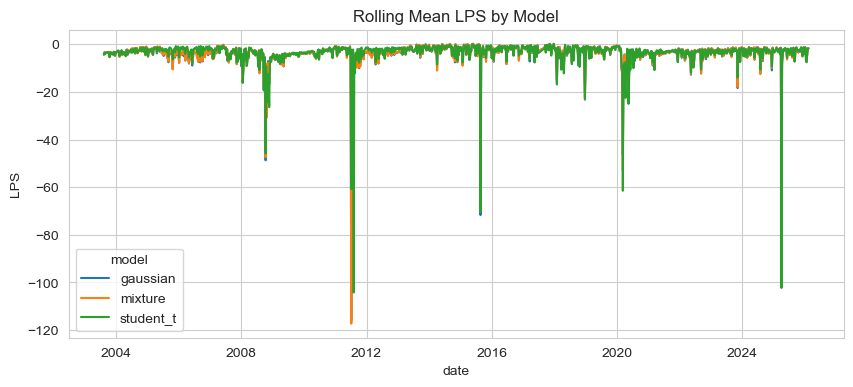

In [17]:
if not detail_all.empty:
    lps_ts = detail_all.groupby(['date', 'model'], as_index=False)['lps'].mean()
    plt.figure(figsize=(10,4))
    sns.lineplot(data=lps_ts, x='date', y='lps', hue='model')
    plt.title('Rolling Mean LPS by Model')
    plt.ylabel('LPS')
    plt.show()


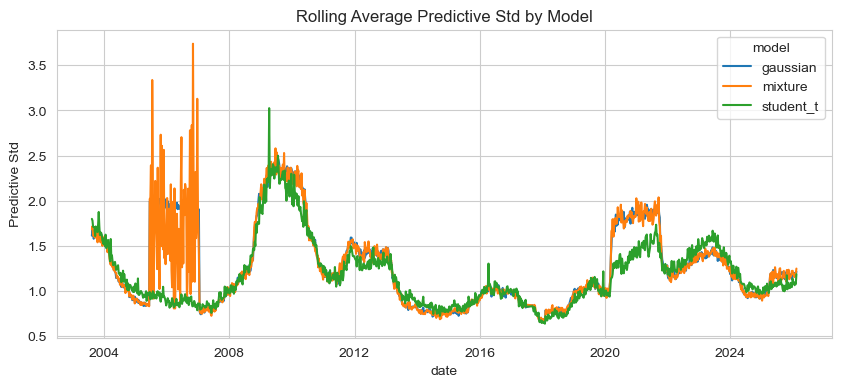

In [18]:
if not detail_all.empty:
    std_ts = detail_all.groupby(['date', 'model'], as_index=False)['pred_std'].mean()
    plt.figure(figsize=(10,4))
    sns.lineplot(data=std_ts, x='date', y='pred_std', hue='model')
    plt.title('Rolling Average Predictive Std by Model')
    plt.ylabel('Predictive Std')
    plt.show()


,model,var_hit_rate,expected_var_rate
0,gaussian,0.063111,0.05
1,mixture,0.067333,0.05
2,student_t,0.074444,0.05


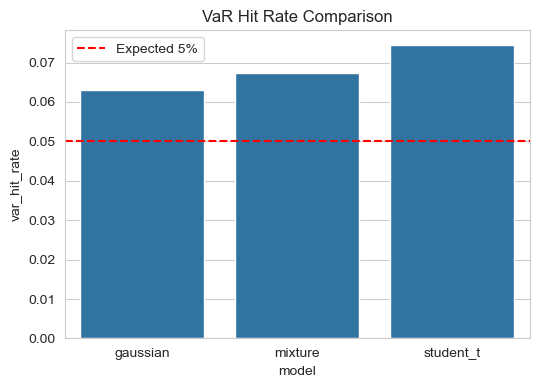

In [19]:
if not detail_all.empty:
    hit_rate = detail_all.groupby('model', as_index=False)['violation'].mean()
    hit_rate = hit_rate.rename(columns={'violation': 'var_hit_rate'})
    hit_rate['expected_var_rate'] = 0.05
    display(hit_rate)

    plt.figure(figsize=(6,4))
    sns.barplot(data=hit_rate, x='model', y='var_hit_rate')
    plt.axhline(0.05, color='red', linestyle='--', label='Expected 5%')
    plt.title('VaR Hit Rate Comparison')
    plt.legend()
    plt.show()


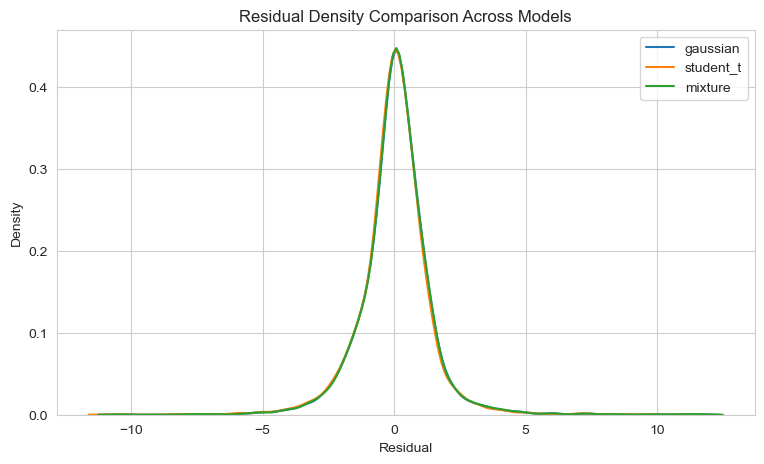

In [20]:
if not detail_all.empty:
    detail_all['residual'] = detail_all['y_true'] - detail_all['pred_mean']
    plt.figure(figsize=(9,5))
    for model in ['gaussian', 'student_t', 'mixture']:
        sub = detail_all[detail_all['model'] == model]['residual']
        if len(sub) > 0:
            sns.kdeplot(sub, label=model)
    plt.title('Residual Density Comparison Across Models')
    plt.xlabel('Residual')
    plt.legend()
    plt.show()


## 8) Rolling forecast summary table with key metrics

We aggregate out-of-sample behavior into reviewer-friendly metrics:
- mean / total LPS,
- average predictive standard deviation,
- VaR hit rate vs expected rate,
- mean ES.


In [21]:
if not detail_all.empty:
    roll_summary = detail_all.groupby('model', as_index=False).agg(
        mean_lps=('lps', 'mean'),
        total_lps=('lps', 'sum'),
        avg_pred_std=('pred_std', 'mean'),
        var_hit_rate=('violation', 'mean'),
        mean_es=('es_alpha', 'mean'),
    )
    roll_summary['expected_var_rate'] = 0.05
    roll_summary = roll_summary.sort_values('mean_lps', ascending=False)
    roll_summary


## 9) Show selected saved figures inline

This section demonstrates that the pipeline creates persistent visual artifacts.


Showing up to 6 saved figures:
- gaussian/figures/actual_vs_predicted_gaussian_20260323_184839.png
- gaussian/figures/predictive_dist_gaussian_20260323_184839.png
- gaussian/figures/residual_hist_gaussian_20260323_184839.png
- gaussian/figures/residual_series_gaussian_20260323_184839.png
- gaussian/figures/var_violations_gaussian_20260323_184839.png
- mixture/figures/actual_vs_predicted_mixture_20260323_184839.png


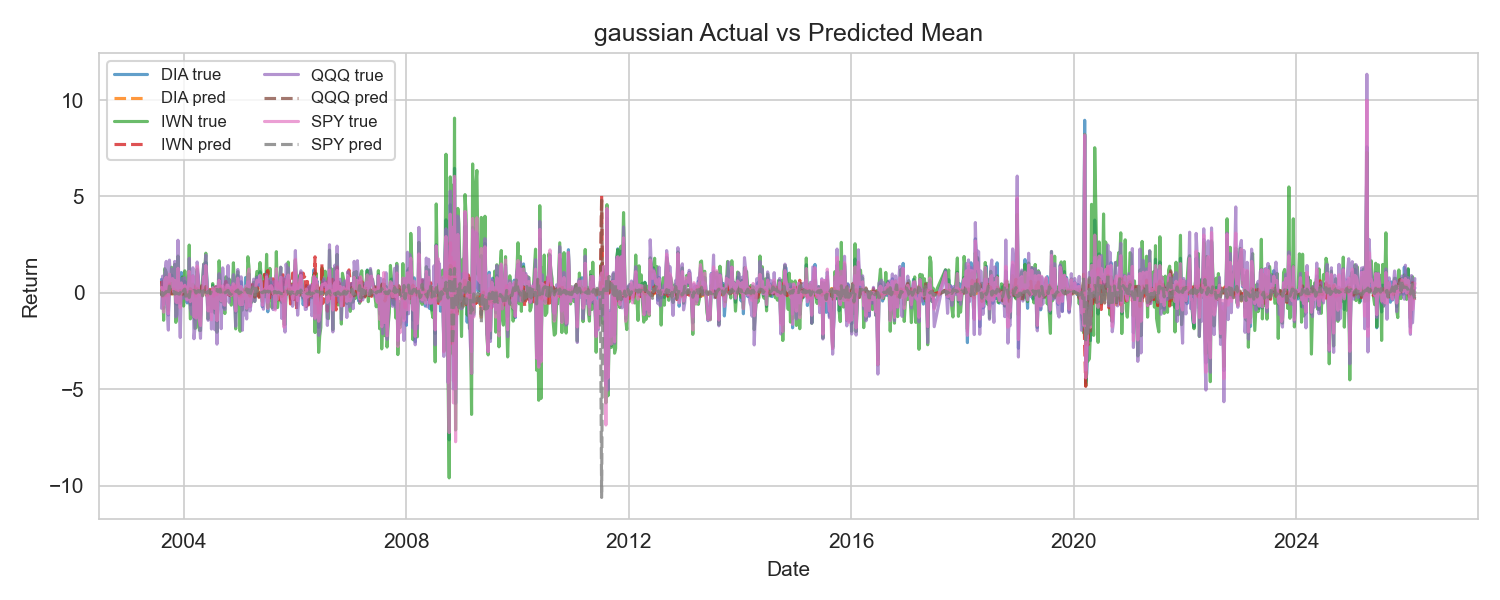

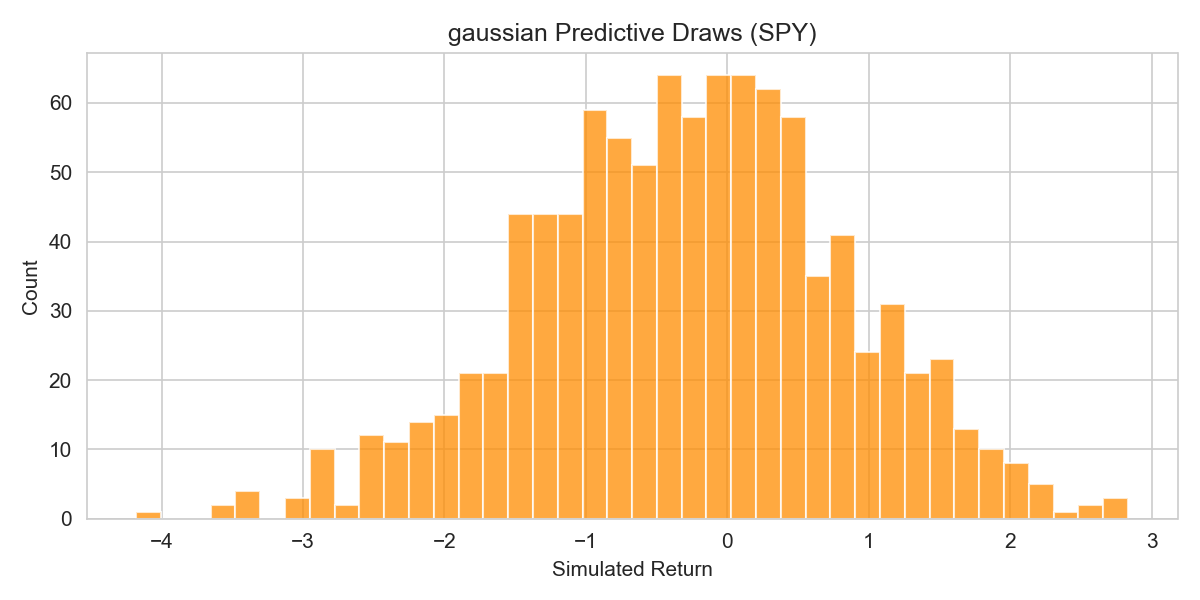

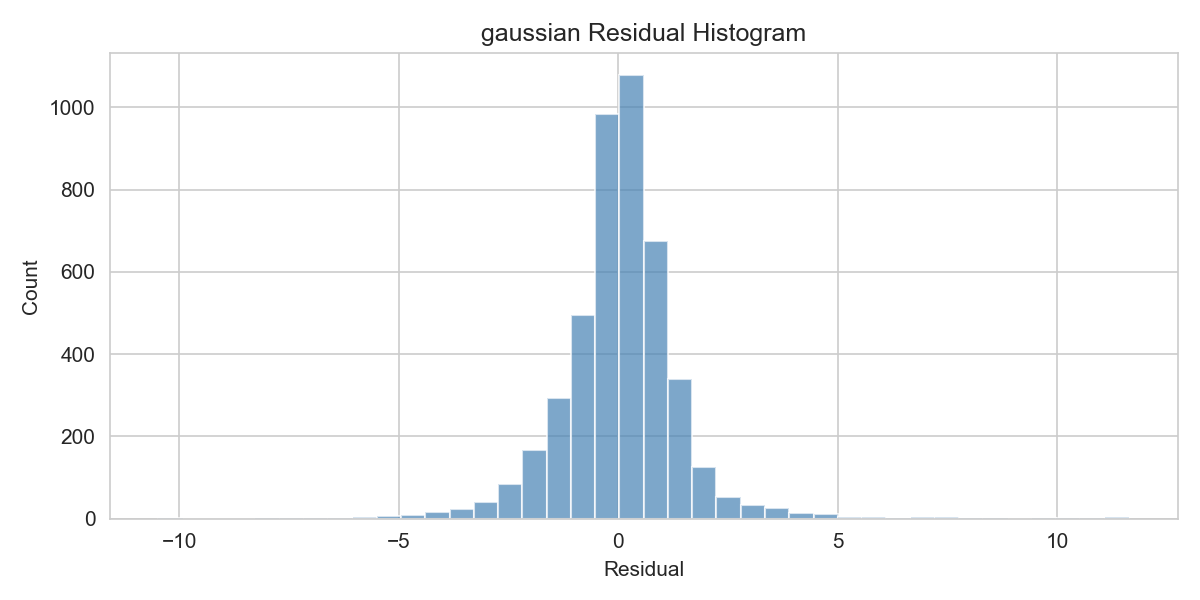

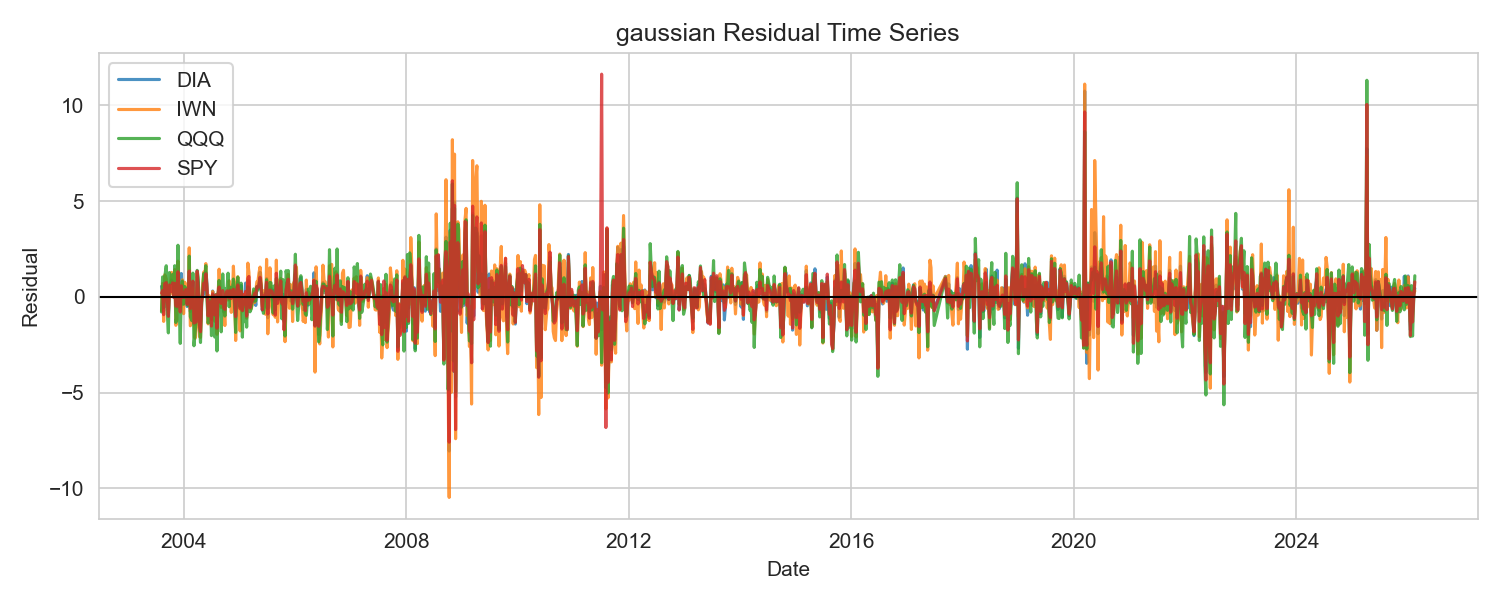

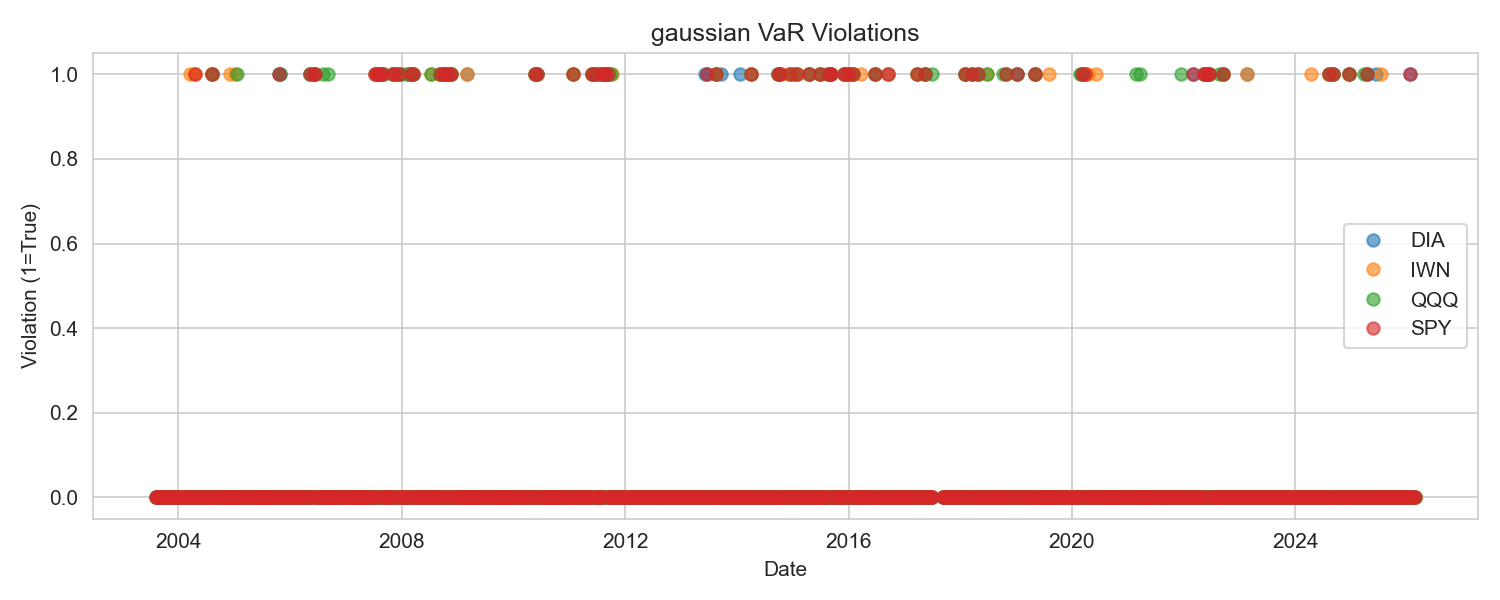

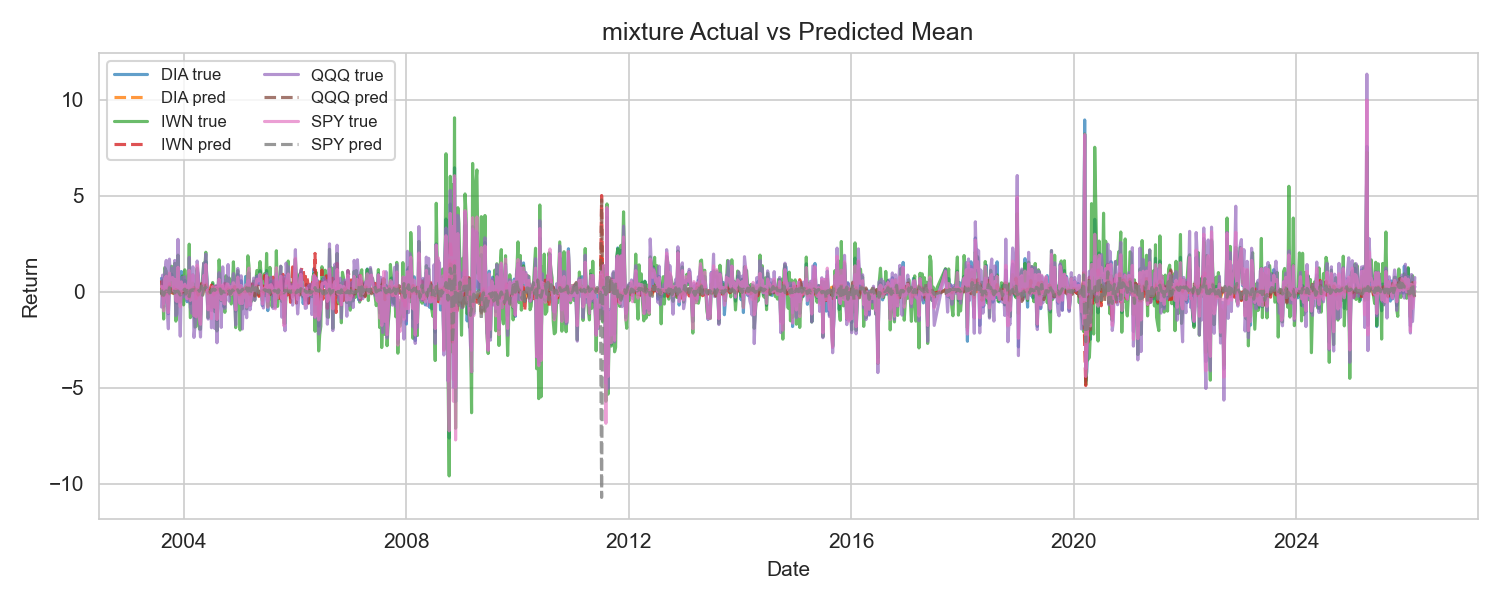

In [22]:
from IPython.display import Image, display

if latest_run_dir is not None:
    selected = sorted(latest_run_dir.rglob('*.png'))[:6]
    print('Showing up to 6 saved figures:')
    for p in selected:
        print('-', p.relative_to(latest_run_dir))
    for p in selected:
        display(Image(filename=str(p), width=500))


## 10) Final summary

This notebook demonstrates the full VAR point-estimation workflow as a reviewer-facing presentation layer.

Key takeaways:
- The project models 4-dimensional returns with a VAR(2) mean structure (9 predictors to 4 outputs).
- It compares Gaussian, Student-t, and Mixture innovation assumptions under rolling one-step forecasting.
- The workflow returns comparison objects and writes structured, timestamped artifacts (metrics + figures) to disk.
- The saved outputs can be reloaded for compact model comparison and risk diagnostics (LPS, predictive std, VaR/ES behavior).

Use this notebook as a concise walkthrough; use the minimal workflow notebook for quick execution checks.
